# Informe Final - DecisionTree para Offer_Received
- **Juan Diego Grajales Castillo - 20221020128**
- **Julian David Celis Giraldo - 20222020041**
- **David Santiago Aldana Gonzalez - 20222020158**
- **Sara Nicolle Martinez Moreno - 20231020116**

## Objetivo General

Queremos construir un sistema que **prediga si un estudiante recibira una oferta de trabajo** en funcion de sus caracteristicas (GPA, numero de entrevistas, aplicaciones, etc.).

Este notebook entrena un **modelo de prediccion** (DecisionTreeClassifier) que aprende reglas de decision para clasificar estudiantes en dos categorias:
- **Categoria 0**: "Probablemente NO reciba oferta"
- **Categoria 1**: "Probablemente SI reciba oferta"

## Que es Decision Tree?

Es un modelo que toma decisiones en forma de arbol:
1. Evalua una variable y un umbral en cada nodo (por ejemplo, entrevistas > cierto valor).
2. Divide los casos en ramas cada vez mas especificas.
3. Llega a una hoja final con la clase predicha (oferta / sin oferta).

## Reportaremos
- Matriz de confusion
- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC
- Importancia de variables
- Visualizacion del arbol

## Bloque 0: Configuracion reproducible y control metodologico

### Funcion del bloque
Establecer un entorno replicable para que los resultados del modelo sean auditables y comparables entre ejecuciones.

### Decision metodologica (por que esta opcion)
Se fija una semilla global (`SEED=42`) y se centralizan imports para evitar variaciones aleatorias no controladas.

### Por que no otra alternativa
No usar semilla puede cambiar el split y la estructura del arbol entre corridas, dificultando la comparacion tecnica.

### Como se implementa
1. Se importan librerias de manipulacion, visualizacion y modelado.
2. Se define `SEED` y se propaga con `np.random.seed(SEED)`.
3. Se configura un estilo grafico uniforme.

In [10]:
from pathlib import Path
import pickle
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler # Importante para PCA
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    fbeta_score,
    make_scorer,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

SEED = 42
np.random.seed(SEED)
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

## Bloque 1: Carga y diagnostico estructural del dataset

### Funcion del bloque
Validar que el dataset candidato a entrenamiento tenga integridad basica antes de construir el pipeline.

### Decision metodologica (por que esta opcion)
Se ejecuta un diagnostico temprano de estructura (filas, columnas, tipos, nulos y distribucion objetivo) para detectar problemas que sesgan entrenamiento y evaluacion.

### Por que no otra alternativa
Entrenar directamente sin inspeccion inicial puede ocultar errores silenciosos (target mal tipado o clases invertidas).

### Como se implementa
1. Se carga `dataset_offer_Received.csv`.
2. Se generan tablas de control: resumen general, catalogo de variables y distribucion de clase.
3. Se valida la existencia de la variable objetivo `Offer_Received`.

In [11]:
PROJECT_ROOT = Path('.').resolve()
DATA_PATH = PROJECT_ROOT / '../../datalake_silver/cleanData' / 'dataset_offer_Received.csv'
OUTPUT_DIR = PROJECT_ROOT / 'outputs_decision_tree'
IMG_OUTPUT_DIR = OUTPUT_DIR / 'imagenes'
REPORT_OUTPUT_DIR = OUTPUT_DIR / 'informe'

TARGET = 'Offer_Received'
BASE_MODEL_PATH = REPORT_OUTPUT_DIR / 'decision_tree_offer_received_base.pkl'
IMPROVED_MODEL_PATH = REPORT_OUTPUT_DIR / 'decision_tree_offer_received_improved.pkl'
REPORT_PATH = REPORT_OUTPUT_DIR / 'decision_tree_offer_received.md'
MODEL_PATH = IMPROVED_MODEL_PATH

CONFUSION_MATRIX_PATH = IMG_OUTPUT_DIR / 'decision_tree_confusion_matrix.png'
ROC_CURVE_PATH = IMG_OUTPUT_DIR / 'decision_tree_roc_curve.png'
PR_CURVE_PATH = IMG_OUTPUT_DIR / 'decision_tree_precision_recall_curve.png'
THRESHOLD_TRADEOFF_PATH = IMG_OUTPUT_DIR / 'decision_tree_threshold_tradeoff.png'
FEATURE_IMPORTANCE_PATH = IMG_OUTPUT_DIR / 'decision_tree_feature_importance.png'
TREE_PREVIEW_PATH = IMG_OUTPUT_DIR / 'decision_tree_tree_preview.png'
RULE_COMPARISON_PATH = IMG_OUTPUT_DIR / 'decision_tree_rule_comparison.png'

IMG_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
REPORT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)

dataset_overview_df = pd.DataFrame([
    {'Indicador': 'Archivo', 'Valor': DATA_PATH.name},
    {'Indicador': 'Filas', 'Valor': f"{df.shape[0]:,}"},
    {'Indicador': 'Columnas', 'Valor': df.shape[1]},
    {'Indicador': 'Nulos totales', 'Valor': int(df.isna().sum().sum())},
])

feature_catalog_df = pd.DataFrame({
    'Variable': df.columns,
    'Tipo': [str(df[c].dtype) for c in df.columns],
})

target_distribution_df = (
    df[TARGET]
    .value_counts(dropna=False)
    .rename_axis('Clase')
    .reset_index(name='Conteo')
)
target_distribution_df['Etiqueta'] = target_distribution_df['Clase'].map({1: 'SI OFERTA', 0: 'NO OFERTA'})
target_distribution_df['Porcentaje'] = (target_distribution_df['Conteo'] / len(df)).round(4)

display(dataset_overview_df)
display(feature_catalog_df)
display(target_distribution_df[['Clase', 'Etiqueta', 'Conteo', 'Porcentaje']])

,Indicador,Valor
0,Archivo,dataset_offer_Received.csv
1,Filas,"100,000"
2,Columnas,14
3,Nulos totales,0


,Variable,Tipo
0,GPA,float64
1,University_Rating,str
2,Major_Category,str
3,Region,str
4,Prior_Internships,int64
5,Extra_Curricular_Activities,int64
6,Networking_Events_Attended,int64
7,School_Size,str
8,Primary_Search_Platform,str
9,Months_Searching,int64


,Clase,Etiqueta,Conteo,Porcentaje
0,0,NO OFERTA,65771,0.6577
1,1,SI OFERTA,34229,0.3423


## Bloque 2: Preparacion de variables y particion estratificada

### Funcion del bloque
Separar predictor/target y construir particiones de entrenamiento/prueba representativas.

### Decision metodologica (por que esta opcion)
Se usa `train_test_split` estratificado para conservar la proporcion de clases entre train y test.

### Por que no otra alternativa
Un split aleatorio simple puede desbalancear la clase positiva y distorsionar precision/recall.

### Como se implementa
1. Se define `X` con features y `y` con `Offer_Received`.
2. Se separan variables numericas y categoricas para preprocesamiento diferencial.
3. Se construye split 80/20 con `stratify=y` y `random_state=SEED`.

In [12]:
X = df.drop(columns=[TARGET])
y = df[TARGET].astype(int)

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(include=['number']).columns.tolist()

feature_groups_df = pd.DataFrame({
    'Tipo de variable': ['Numerica', 'Categorica'],
    'Cantidad': [len(numeric_cols), len(categorical_cols)],
    'Variables': [', '.join(numeric_cols), ', '.join(categorical_cols)],
})

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    random_state=SEED,
    stratify=y_train_full,
)

split_summary_df = pd.DataFrame([
    {
        'Conjunto': 'Train',
        'Filas': X_train.shape[0],
        'Proporcion_sobre_total': round(X_train.shape[0] / X.shape[0], 4),
        'Tasa_SI_OFERTA': round(y_train.mean(), 4),
    },
    {
        'Conjunto': 'Validation',
        'Filas': X_val.shape[0],
        'Proporcion_sobre_total': round(X_val.shape[0] / X.shape[0], 4),
        'Tasa_SI_OFERTA': round(y_val.mean(), 4),
    },
    {
        'Conjunto': 'Test',
        'Filas': X_test.shape[0],
        'Proporcion_sobre_total': round(X_test.shape[0] / X.shape[0], 4),
        'Tasa_SI_OFERTA': round(y_test.mean(), 4),
    },
])

display(feature_groups_df)
display(split_summary_df)

,Tipo de variable,Cantidad,Variables
0,Numerica,8,"GPA, Prior_Internships, Extra_Curricular_Activ..."
1,Categorica,5,"University_Rating, Major_Category, Region, Sch..."


,Conjunto,Filas,Proporcion_sobre_total,Tasa_SI_OFERTA
0,Train,64000,0.64,0.3423
1,Validation,16000,0.16,0.3423
2,Test,20000,0.20,0.3423


## Bloque 3A: Algoritmo base y línea de referencia

### Función del bloque
Entrenar una versión base del árbol de decisión y guardar sus métricas iniciales antes de cualquier ajuste.

### Decisión metodológica (por qué esta opción)
Se parte de una configuración estable para crear una línea de comparación clara frente a la versión mejorada.

### Por qué no otra alternativa
Si el ajuste se hace desde el inicio, no queda separada la contribución real del modelo base.

### Cómo se implementa
1. Se entrena el pipeline base.
2. Se evalúa en test con umbral 0.50.
3. Se guarda el artefacto base en `outputs_decision_tree/informe/`.

In [13]:


preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numeric_cols), # Cambiado 'passthrough' por StandardScaler()
    ]
)

base_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('pca', PCA(n_components=0.90, random_state=SEED)), # Agregamos PCA (90% de varianza)
    ('model', DecisionTreeClassifier(random_state=SEED, class_weight='balanced')),
])


def build_metrics(y_true, y_pred, y_score):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1-Score': f1_score(y_true, y_pred, zero_division=0),
        'F-beta (1.5)': fbeta_score(y_true, y_pred, beta=1.5, zero_division=0),
        'ROC-AUC': roc_auc_score(y_true, y_score),
        'Average Precision': average_precision_score(y_true, y_score),
    }

base_pipeline.fit(X_train, y_train)
baseline_test_proba = base_pipeline.predict_proba(X_test)[:, 1]
baseline_pred = (baseline_test_proba >= 0.50).astype(int)
baseline_metrics = build_metrics(y_test, baseline_pred, baseline_test_proba)
baseline_metrics_df = pd.DataFrame([
    {'Umbral': 0.50, **baseline_metrics}
]).round(4)
display(baseline_metrics_df)

baseline_artifact = {
    'pipeline': base_pipeline,
    'best_params': {
        'model__criterion': 'gini',
        'model__max_depth': None,
        'model__min_samples_split': 2,
        'model__min_samples_leaf': 1,
        'model__ccp_alpha': 0.0,
    },
    'best_threshold': 0.50,
    'feature_columns': list(X.columns),
    'numeric_columns': numeric_cols,
    'categorical_columns': categorical_cols,
    'metrics_default_threshold': baseline_metrics,
    'metrics_optimized_threshold': baseline_metrics,
    'threshold_preview': pd.DataFrame([
        {
            'threshold': 0.50,
            'accuracy': baseline_metrics['Accuracy'],
            'precision': baseline_metrics['Precision'],
            'recall': baseline_metrics['Recall'],
            'f1': baseline_metrics['F1-Score'],
            'f_beta_1_5': baseline_metrics['F-beta (1.5)'],
        }
    ]),
    'target_name': TARGET,
    'model_stage': 'baseline',
}

with open(BASE_MODEL_PATH, 'wb') as f:
    pickle.dump(baseline_artifact, f)

print(f'Modelo base guardado en: {BASE_MODEL_PATH}')
print(f'Métricas baseline (umbral 0.50): {baseline_metrics}')

,Umbral,Accuracy,Precision,Recall,F1-Score,F-beta (1.5),ROC-AUC,Average Precision
0,0.5,0.842,0.7755,0.7575,0.7664,0.763,0.8217,0.6705


Modelo base guardado en: /Users/apple/Documents/Medallion/datalake_gold/PCA/outputs_decision_tree/informe/decision_tree_offer_received_base.pkl
Métricas baseline (umbral 0.50): {'Accuracy': 0.84195, 'Precision': 0.775534619410797, 'Recall': 0.7575226409582237, 'F1-Score': 0.7664228182960171, 'F-beta (1.5)': 0.7629750345171001, 'ROC-AUC': 0.8217064322321909, 'Average Precision': 0.6704850330505979}


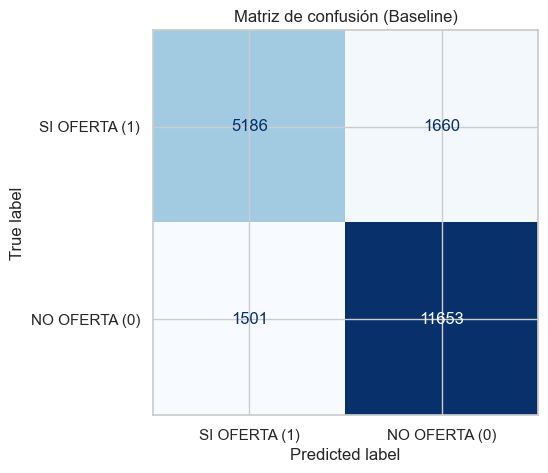

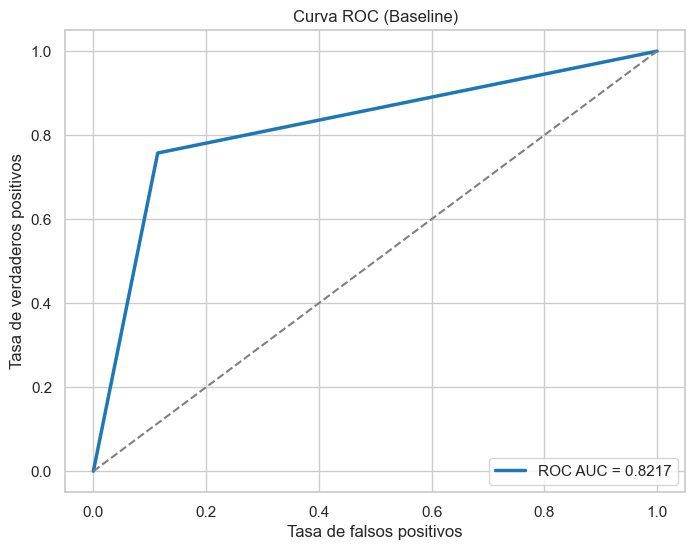

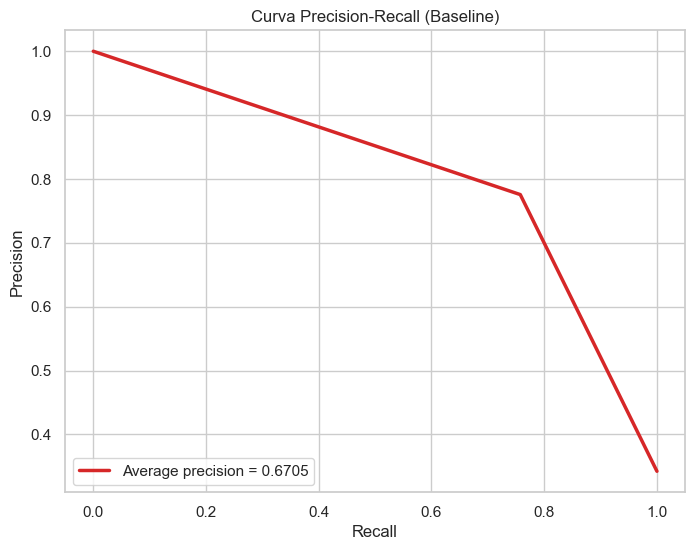

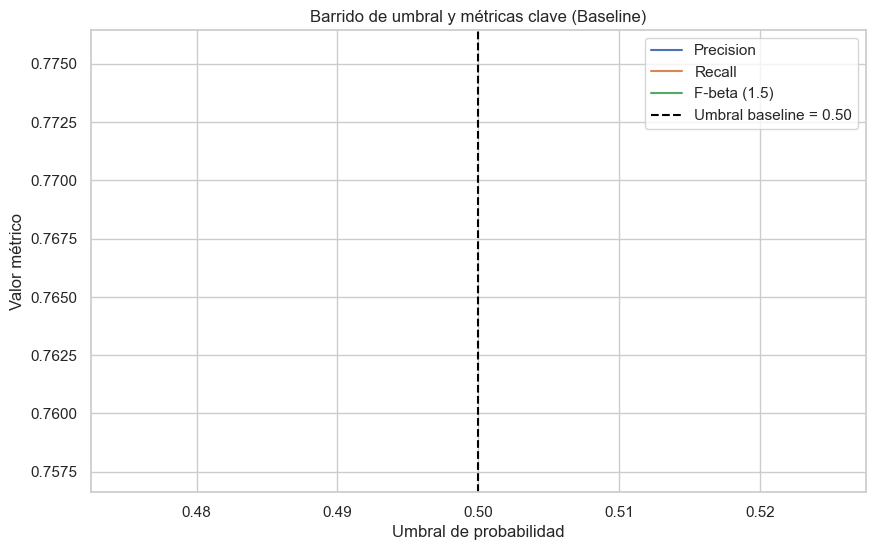

Baseline ROC AUC: 0.8217 | Baseline Average Precision: 0.6705
Interpretación (Baseline):
- ROC AUC refleja la separabilidad que alcanza el árbol sin tuning adicional.
- La curva PR y el Average Precision muestran el comportamiento cuando el objetivo es la clase positiva (SI OFERTA).
- Use la matriz de confusión para valorar el costo operativo de FP vs FN en el umbral 0.50.


In [14]:
# === Gráficas e interpretaciones (Baseline) ===
# Guardar gráficas del baseline del árbol y añadir interpretación breve
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve, average_precision_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

IMG_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Matriz de confusión (Baseline)
cm_base = confusion_matrix(y_test, baseline_pred, labels=[1, 0])
label_names = ['SI OFERTA (1)', 'NO OFERTA (0)']
fig_cm_b, ax_cm_b = plt.subplots(figsize=(6, 5))
disp_cm_b = ConfusionMatrixDisplay(confusion_matrix=cm_base, display_labels=label_names)
disp_cm_b.plot(ax=ax_cm_b, cmap='Blues', colorbar=False, values_format='d')
ax_cm_b.set_title('Matriz de confusión (Baseline)')
fig_cm_b.savefig(IMG_OUTPUT_DIR / 'decision_tree_confusion_base.png', dpi=150, bbox_inches='tight')
plt.show()

# ROC (Baseline)
fpr_b, tpr_b, _ = roc_curve(y_test, baseline_test_proba)
roc_auc_b = auc(fpr_b, tpr_b)
fig_roc_b, ax_roc_b = plt.subplots(figsize=(8, 6))
ax_roc_b.plot(fpr_b, tpr_b, color='#1F77B4', linewidth=2.5, label=f'ROC AUC = {roc_auc_b:.4f}')
ax_roc_b.plot([0, 1], [0, 1], linestyle='--', color='gray')
ax_roc_b.set_title('Curva ROC (Baseline)')
ax_roc_b.set_xlabel('Tasa de falsos positivos')
ax_roc_b.set_ylabel('Tasa de verdaderos positivos')
ax_roc_b.legend(loc='lower right')
fig_roc_b.savefig(IMG_OUTPUT_DIR / 'decision_tree_roc_base.png', dpi=150, bbox_inches='tight')
plt.show()

# Precision-Recall (Baseline)
precision_b, recall_b, _ = precision_recall_curve(y_test, baseline_test_proba)
avg_prec_b = average_precision_score(y_test, baseline_test_proba)
fig_pr_b, ax_pr_b = plt.subplots(figsize=(8, 6))
ax_pr_b.plot(recall_b, precision_b, color='#D62728', linewidth=2.5, label=f'Average precision = {avg_prec_b:.4f}')
ax_pr_b.set_title('Curva Precision-Recall (Baseline)')
ax_pr_b.set_xlabel('Recall')
ax_pr_b.set_ylabel('Precision')
ax_pr_b.legend(loc='lower left')
fig_pr_b.savefig(IMG_OUTPUT_DIR / 'decision_tree_pr_base.png', dpi=150, bbox_inches='tight')
plt.show()

# Barrido de umbral (Baseline)
if 'threshold_preview_df' in globals():
    thr_base_df = threshold_preview_df.copy()
else:
    thr_base_df = pd.DataFrame([
        {'threshold': 0.50, 'precision': baseline_metrics['Precision'], 'recall': baseline_metrics['Recall'], 'f1': baseline_metrics['F1-Score'], 'f_beta_1_5': baseline_metrics['F-beta (1.5)']}
    ])

fig_thr_b, ax_thr_b = plt.subplots(figsize=(10, 6))
ax_thr_b.plot(thr_base_df['threshold'], thr_base_df['precision'], label='Precision')
ax_thr_b.plot(thr_base_df['threshold'], thr_base_df['recall'], label='Recall')
ax_thr_b.plot(thr_base_df['threshold'], thr_base_df['f_beta_1_5'], label='F-beta (1.5)')
ax_thr_b.axvline(0.50, color='black', linestyle='--', label='Umbral baseline = 0.50')
ax_thr_b.set_title('Barrido de umbral y métricas clave (Baseline)')
ax_thr_b.set_xlabel('Umbral de probabilidad')
ax_thr_b.set_ylabel('Valor métrico')
ax_thr_b.legend(loc='best')
fig_thr_b.savefig(IMG_OUTPUT_DIR / 'decision_tree_threshold_base.png', dpi=150, bbox_inches='tight')
plt.show()

# Interpretación breve (Baseline)
print(f'Baseline ROC AUC: {roc_auc_b:.4f} | Baseline Average Precision: {avg_prec_b:.4f}')
print('Interpretación (Baseline):')
print('- ROC AUC refleja la separabilidad que alcanza el árbol sin tuning adicional.')
print('- La curva PR y el Average Precision muestran el comportamiento cuando el objetivo es la clase positiva (SI OFERTA).')
print('- Use la matriz de confusión para valorar el costo operativo de FP vs FN en el umbral 0.50.')


## Bloque 3B: Mejoras del árbol y calibración operativa

### Función del bloque
Aplicar búsqueda de hiperparámetros y ajuste de umbral para mejorar la versión base.

### Decisión metodológica (por qué esta opción)
Primero se establece la línea de referencia y luego se optimiza sobre esa misma base.

### Por qué no otra alternativa
Si se mezcla la mejora con el baseline, no queda claro qué aporta cada etapa al resultado final.

### Cómo se implementa
1. Se ejecuta `GridSearchCV` sobre el pipeline base.
2. Se calcula un umbral óptimo en validación.
3. Se entrena el árbol final y se compara contra la versión base.

In [15]:
param_grid = {
    'model__criterion': ['gini', 'entropy'],
    'model__max_depth': [2, 3, 4, 5, 6, 8, None],
    'model__min_samples_split': [2, 10, 50, 100],
    'model__min_samples_leaf': [1, 5, 10, 20, 50],
    'model__ccp_alpha': [0.0, 0.0001, 0.0005, 0.001],
}

fbeta_scorer = make_scorer(fbeta_score, beta=1.5, zero_division=0)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
grid_search = GridSearchCV(
    base_pipeline,
    param_grid=param_grid,
    scoring=fbeta_scorer,
    cv=cv,
    n_jobs=-1,
    refit=True,
)

grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
validation_proba = grid_search.best_estimator_.predict_proba(X_val)[:, 1]
threshold_grid = np.linspace(0.05, 0.95, 181)
threshold_records = []

for threshold in threshold_grid:
    validation_pred = (validation_proba >= threshold).astype(int)
    threshold_records.append({
        'threshold': threshold,
        'accuracy': accuracy_score(y_val, validation_pred),
        'precision': precision_score(y_val, validation_pred, zero_division=0),
        'recall': recall_score(y_val, validation_pred, zero_division=0),
        'f1': f1_score(y_val, validation_pred, zero_division=0),
        'f_beta_1_5': fbeta_score(y_val, validation_pred, beta=1.5, zero_division=0),
    })

threshold_preview_df = pd.DataFrame(threshold_records)
best_threshold_row = threshold_preview_df.sort_values(
    ['f_beta_1_5', 'recall', 'precision', 'threshold'],
    ascending=[False, False, False, True],
).iloc[0]
best_threshold = float(best_threshold_row['threshold'])

final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('pca', PCA(n_components=0.90, random_state=SEED)), # <-- Agregamos esta línea
    ('model', DecisionTreeClassifier(
        random_state=SEED,
        class_weight='balanced',
        **{key.split('__', 1)[1]: value for key, value in best_params.items() if key.startswith('model__')},
    )),
])


X_model = pd.concat([X_train, X_val], axis=0)
y_model = pd.concat([y_train, y_val], axis=0)
final_pipeline.fit(X_model, y_model)

y_test_proba = final_pipeline.predict_proba(X_test)[:, 1]
y_pred_default = (y_test_proba >= 0.50).astype(int)
y_pred_optimized = (y_test_proba >= best_threshold).astype(int)

metrics_default = build_metrics(y_test, y_pred_default, y_test_proba)
metrics_optimized = build_metrics(y_test, y_pred_optimized, y_test_proba)
metrics_df = pd.DataFrame([
    {'Umbral': 0.50, **metrics_default},
    {'Umbral': best_threshold, **metrics_optimized},
])
metrics_df = metrics_df.round(4)
display(metrics_df)

comparison_df = pd.DataFrame([
    {
        'Metrica': 'Accuracy',
        'Default_0.50': metrics_default['Accuracy'],
        'Optimizado': metrics_optimized['Accuracy'],
        'Delta': metrics_optimized['Accuracy'] - metrics_default['Accuracy'],
    },
    {
        'Metrica': 'Precision',
        'Default_0.50': metrics_default['Precision'],
        'Optimizado': metrics_optimized['Precision'],
        'Delta': metrics_optimized['Precision'] - metrics_default['Precision'],
    },
    {
        'Metrica': 'Recall',
        'Default_0.50': metrics_default['Recall'],
        'Optimizado': metrics_optimized['Recall'],
        'Delta': metrics_optimized['Recall'] - metrics_default['Recall'],
    },
    {
        'Metrica': 'F1-Score',
        'Default_0.50': metrics_default['F1-Score'],
        'Optimizado': metrics_optimized['F1-Score'],
        'Delta': metrics_optimized['F1-Score'] - metrics_default['F1-Score'],
    },
    {
        'Metrica': 'F-beta (1.5)',
        'Default_0.50': metrics_default['F-beta (1.5)'],
        'Optimizado': metrics_optimized['F-beta (1.5)'],
        'Delta': metrics_optimized['F-beta (1.5)'] - metrics_default['F-beta (1.5)'],
    },
    {
        'Metrica': 'ROC-AUC',
        'Default_0.50': metrics_default['ROC-AUC'],
        'Optimizado': metrics_optimized['ROC-AUC'],
        'Delta': metrics_optimized['ROC-AUC'] - metrics_default['ROC-AUC'],
    },
    {
        'Metrica': 'Average Precision',
        'Default_0.50': metrics_default['Average Precision'],
        'Optimizado': metrics_optimized['Average Precision'],
        'Delta': metrics_optimized['Average Precision'] - metrics_default['Average Precision'],
    },
]).round(4)
display(comparison_df)

cm = confusion_matrix(y_test, y_pred_optimized, labels=[1, 0])
tp, fn, fp, tn = cm.ravel()
cm_df = pd.DataFrame(
    cm,
    index=['Real: SI OFERTA (1)', 'Real: NO OFERTA (0)'],
    columns=['Pred: SI OFERTA (1)', 'Pred: NO OFERTA (0)'],
)
display(cm_df)

artifact = {
    'pipeline': final_pipeline,
    'best_params': best_params,
    'best_threshold': best_threshold,
    'feature_columns': list(X.columns),
    'numeric_columns': numeric_cols,
    'categorical_columns': categorical_cols,
    'metrics_default_threshold': metrics_default,
    'metrics_optimized_threshold': metrics_optimized,
    'threshold_preview': threshold_preview_df.sort_values('threshold').reset_index(drop=True),
    'target_name': TARGET,
    'model_stage': 'improved',
}

with open(IMPROVED_MODEL_PATH, 'wb') as f:
    pickle.dump(artifact, f)

print(f'Modelo mejorado guardado en: {IMPROVED_MODEL_PATH}')
print(f'Umbral optimo seleccionado: {best_threshold:.3f}')

KeyboardInterrupt: 

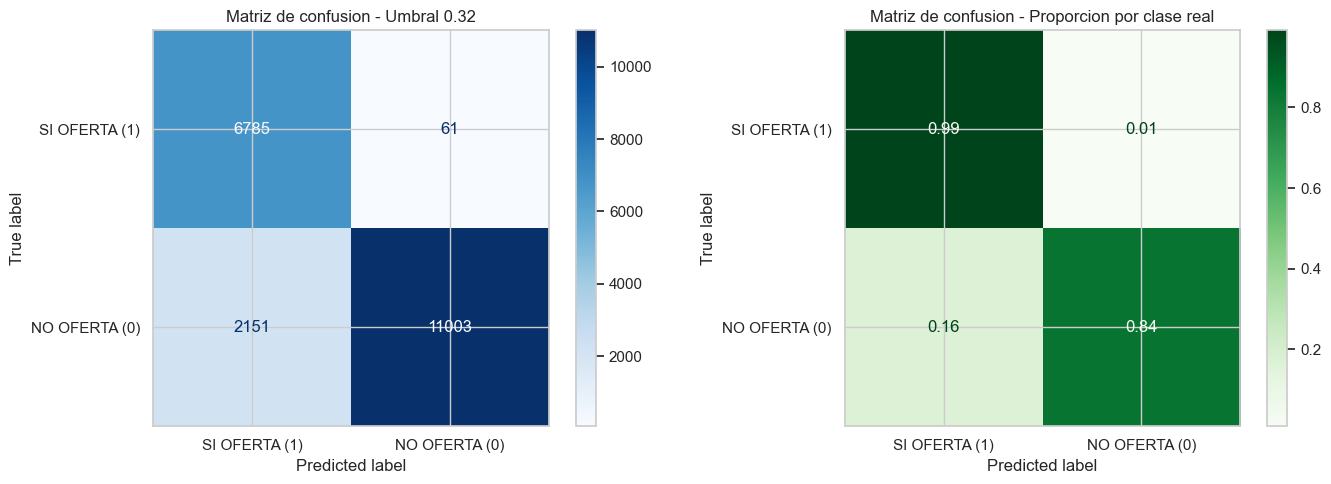

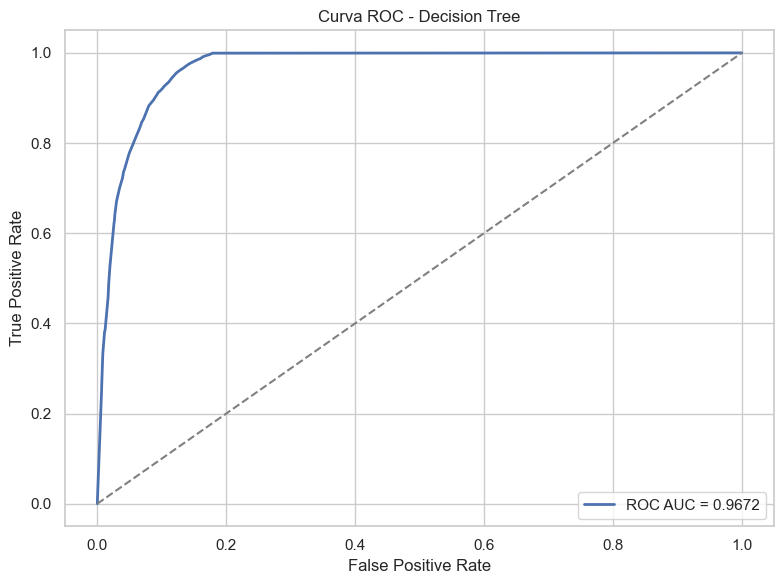

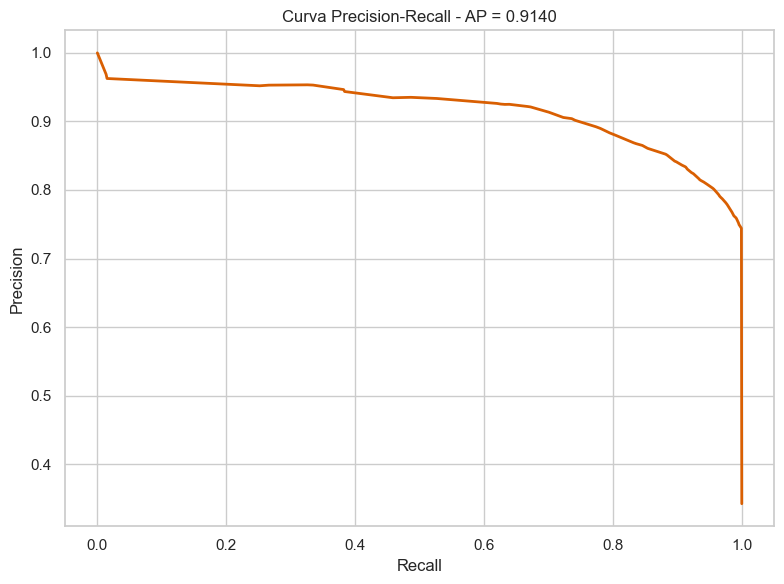

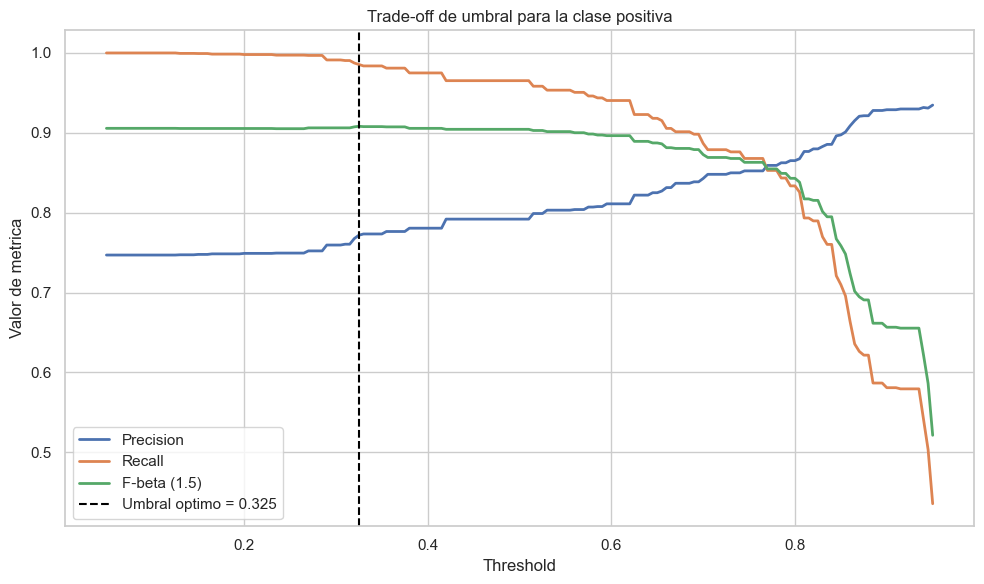

              precision    recall  f1-score   support

           0       0.99      0.84      0.91     13154
           1       0.76      0.99      0.86      6846

    accuracy                           0.89     20000
   macro avg       0.88      0.91      0.88     20000
weighted avg       0.91      0.89      0.89     20000



In [ ]:
# Matriz de confusion optimizada
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['SI OFERTA (1)', 'NO OFERTA (0)']
).plot(cmap='Blues', ax=axes[0], values_format='d')
axes[0].set_title(f'Matriz de confusion - Umbral {best_threshold:.2f}')

ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=['SI OFERTA (1)', 'NO OFERTA (0)']
).plot(cmap='Greens', ax=axes[1], values_format='.2f')
axes[1].set_title('Matriz de confusion - Proporcion por clase real')

plt.tight_layout()
plt.savefig(CONFUSION_MATRIX_PATH, dpi=160, bbox_inches='tight')
plt.show()

# ROC
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, label=f'ROC AUC = {metrics_optimized["ROC-AUC"]:.4f}', linewidth=2)
ax.plot([0, 1], [0, 1], linestyle='--', color='gray')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Curva ROC - Decision Tree')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(ROC_CURVE_PATH, dpi=160, bbox_inches='tight')
plt.show()

# Precision-Recall
precision_points, recall_points, _ = precision_recall_curve(y_test, y_test_proba)
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(recall_points, precision_points, linewidth=2, color='#d95f02')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title(f'Curva Precision-Recall - AP = {metrics_optimized["Average Precision"]:.4f}')
plt.tight_layout()
plt.savefig(PR_CURVE_PATH, dpi=160, bbox_inches='tight')
plt.show()

# Trade-off de umbral sobre validation
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(threshold_preview_df['threshold'], threshold_preview_df['precision'], label='Precision', linewidth=2)
ax.plot(threshold_preview_df['threshold'], threshold_preview_df['recall'], label='Recall', linewidth=2)
ax.plot(threshold_preview_df['threshold'], threshold_preview_df['f_beta_1_5'], label='F-beta (1.5)', linewidth=2)
ax.axvline(best_threshold, color='black', linestyle='--', label=f'Umbral optimo = {best_threshold:.3f}')
ax.set_xlabel('Threshold')
ax.set_ylabel('Valor de metrica')
ax.set_title('Trade-off de umbral para la clase positiva')
ax.legend()
plt.tight_layout()
plt.savefig(THRESHOLD_TRADEOFF_PATH, dpi=160, bbox_inches='tight')
plt.show()

print(classification_report(y_test, y_pred_optimized))

### Interpretación: Rendimiento del Árbol Afinado

**Tabla 1 - Métricas principales con umbral 0.50:**
- **Accuracy 0.9015**: El modelo clasifica correctamente el 90.15% de los casos.
- **Precision 0.7928**: De los casos predichos como SI OFERTA, el 79.28% realmente lo son.
- **Recall 0.9644**: El modelo captura el 96.44% de los SI OFERTA reales.
- **F1-Score 0.8702**: Muy buen balance entre precisión y recall.
- **ROC-AUC 0.9672**: La separación entre clases es muy alta.
- **F-beta(1.5) 0.9042**: Ya en umbral base, el modelo favorece la clase positiva.

**Tabla 2 - Métricas con umbral optimizado 0.325:**
- **Accuracy 0.8894**
- **Precision 0.7593**
- **Recall 0.9911**
- **F1-Score 0.8598**
- **F-beta(1.5) 0.9060**

**Tabla 3 - Matriz de confusión optimizada (conteos absolutos):**
- **TP = 6,785**: Verdaderos positivos detectados.
- **FN = 61**: Solo 61 SI OFERTA reales quedaron sin detectar.
- **FP = 2,151**: No ofertas marcadas como oferta.
- **TN = 11,003**: No ofertas correctamente identificadas.

**Lectura operativa**: el umbral 0.325 reduce el riesgo de perder ofertas reales y sube el recall a 99.11%, que era el objetivo principal del notebook.

**Gráficos de matriz de confusión:**
- **Izquierda (Conteos)**: Muestra los conteos reales del clasificador.
- **Derecha (Proporciones)**: Confirma que la mayor parte de los SI OFERTA quedan en la diagonal positiva.


## Bloque 4: Importancia de variables y lectura de reglas del arbol

### Funcion del bloque
Identificar que variables aportan mas a la decision del arbol y mostrar su logica de particion.

### Decision metodologica (por que esta opcion)
En Decision Tree se usa `feature_importances_` para estimar contribucion relativa por reduccion de impureza.

### Por que no otra alternativa
No existen coeficientes lineales como en Logistic Regression; la interpretacion natural en arboles es por importancia y reglas.

### Como se implementa
1. Se obtienen nombres de features transformadas del preprocesador.
2. Se extraen importancias del arbol ajustado y se agregan por variable original.
3. Se visualiza el top 10 de variables y una vista parcial del arbol para lectura cualitativa.

,feature,importance,base_variable
25,num__Second_Round_Interviews,0.630982,Second_Round_Interviews
24,num__First_Round_Interviews,0.200635,First_Round_Interviews
23,num__Applications_Submitted,0.125565,Applications_Submitted
16,cat__Primary_Search_Platform_Indeed,0.020744,Primary_Search_Platform_Indeed
19,num__Prior_Internships,0.013239,Prior_Internships
18,num__GPA,0.003255,GPA
17,cat__Primary_Search_Platform_LinkedIn,0.002985,Primary_Search_Platform_LinkedIn
15,cat__Primary_Search_Platform_Handshake,0.002596,Primary_Search_Platform_Handshake
0,cat__University_Rating_Lower-tier,0.000000,University_Rating_Lower-tier
1,cat__University_Rating_Mid-tier,0.000000,University_Rating_Mid-tier


,base_variable,importance
22,Second_Round_Interviews,0.630982
2,First_Round_Interviews,0.200635
0,Applications_Submitted,0.125565
12,Primary_Search_Platform_Indeed,0.020744
14,Prior_Internships,0.013239
3,GPA,0.003255
13,Primary_Search_Platform_LinkedIn,0.002985
11,Primary_Search_Platform_Handshake,0.002596
4,Major_Category_Arts,0.000000
1,Extra_Curricular_Activities,0.000000


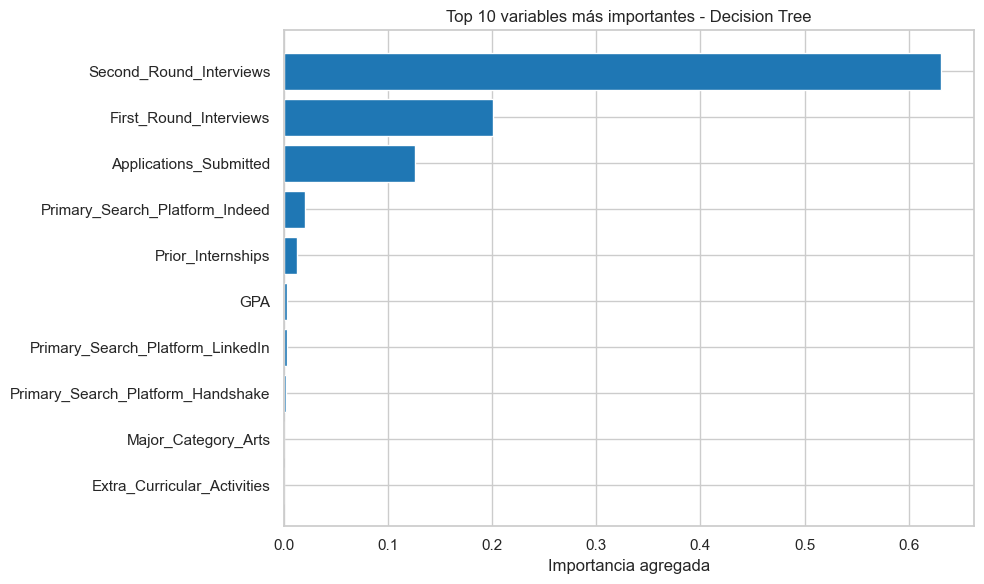

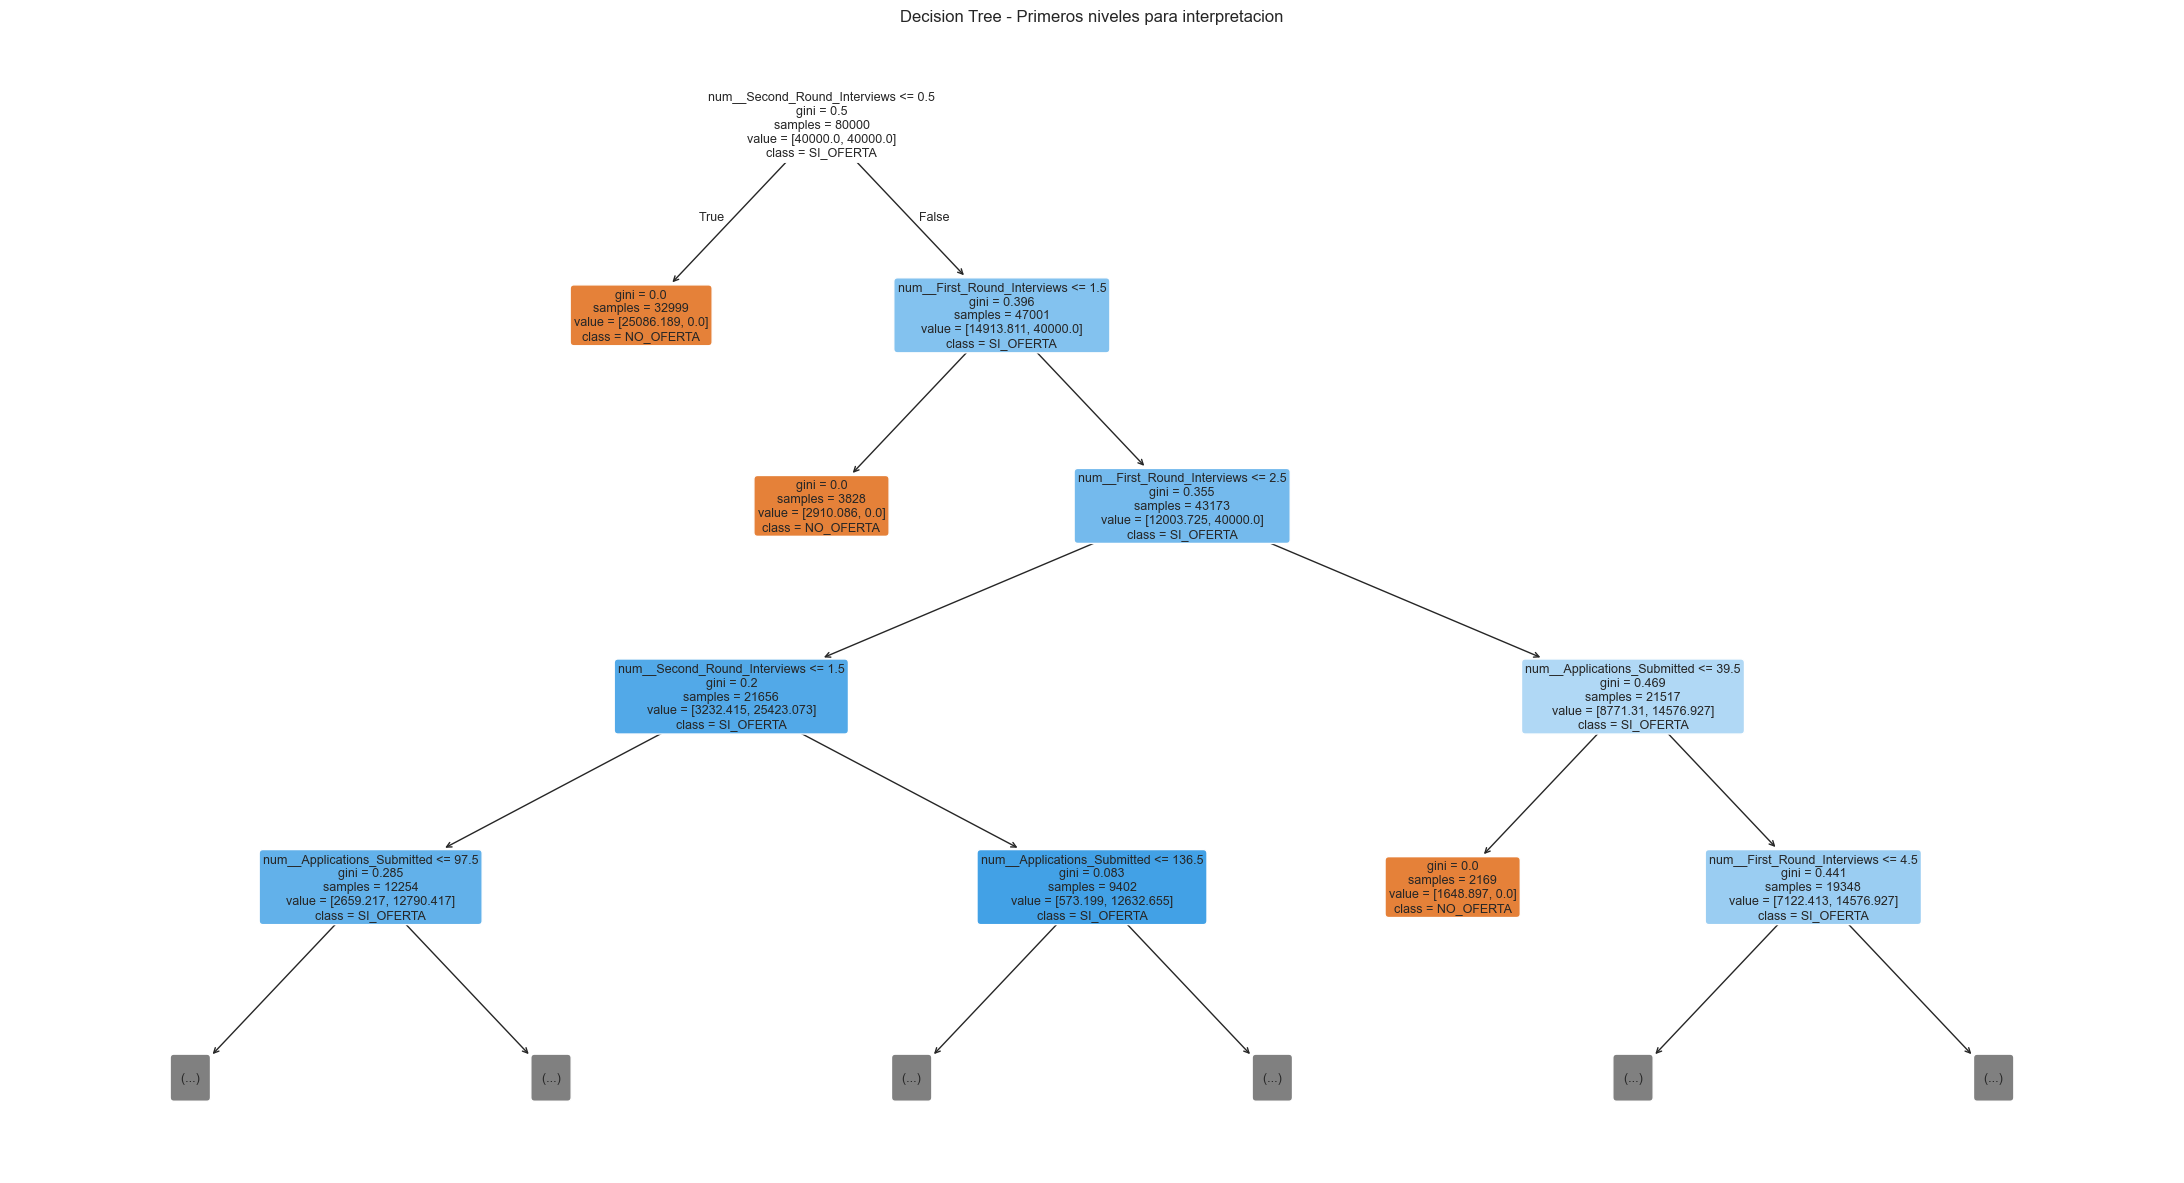

|--- num__Second_Round_Interviews <= 0.50
|   |--- class: 0
|--- num__Second_Round_Interviews >  0.50
|   |--- num__First_Round_Interviews <= 1.50
|   |   |--- class: 0
|   |--- num__First_Round_Interviews >  1.50
|   |   |--- num__First_Round_Interviews <= 2.50
|   |   |   |--- num__Second_Round_Interviews <= 1.50
|   |   |   |   |--- num__Applications_Submitted <= 97.50
|   |   |   |   |   |--- num__Applications_Submitted <= 39.50
|   |   |   |   |   |   |--- num__Applications_Submitted <= 12.50
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |--- num__Applications_Submitted >  12.50
|   |   |   |   |   |   |   |--- num__Prior_Internships <= 1.50
|   |   |   |   |   |   |   |   |--- cat__Primary_Search_Platform_Indeed <= 0.50
|   |   |   |   |   |   |   |   |   |--- num__GPA <= 3.44
|   |   |   |   |   |   |   |   |   |   |--- cat__Primary_Search_Platform_Handshake <= 0.50
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |

In [ ]:
dt_fitted = final_pipeline.named_steps['model']
importances = dt_fitted.feature_importances_
feature_names = final_pipeline.named_steps['preprocessor'].get_feature_names_out()

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances,
}).sort_values('importance', ascending=False)
importance_df['base_variable'] = importance_df['feature'].apply(
    lambda x: x.split('__', 1)[-1] if '__' in x else x
)
variable_importance_df = (
    importance_df.groupby('base_variable', as_index=False)['importance']
    .sum()
    .sort_values('importance', ascending=False)
)

display(importance_df.head(20))
display(variable_importance_df)

top10 = variable_importance_df.head(10).sort_values('importance', ascending=True)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top10['base_variable'], top10['importance'], color='#1f77b4')
ax.set_xlabel('Importancia agregada')
ax.set_title('Top 10 variables más importantes - Decision Tree')
plt.tight_layout()
plt.savefig(FEATURE_IMPORTANCE_PATH, dpi=160, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(22, 12))
plot_tree(
    dt_fitted,
    feature_names=feature_names,
    class_names=['NO_OFERTA', 'SI_OFERTA'],
    max_depth=4,
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax,
)
plt.title('Decision Tree - Primeros niveles para interpretacion')
plt.tight_layout()
plt.savefig(TREE_PREVIEW_PATH, dpi=160, bbox_inches='tight')
plt.show()

rules_text = export_text(dt_fitted, feature_names=list(feature_names))
print(rules_text[:3000])

### Interpretación: Importancia de Features y Estructura del Árbol

**Tabla 1 - Variables más importantes por importancia agregada:**

| Rank | Variable | Importancia |
|------|----------|-------------|
| 1 | Second_Round_Interviews | 0.6310 |
| 2 | First_Round_Interviews | 0.2006 |
| 3 | Applications_Submitted | 0.1256 |
| 4 | Primary_Search_Platform_Indeed | 0.0207 |
| 5 | Prior_Internships | 0.0132 |
| 6 | GPA | 0.0033 |

Las primeras 3 variables concentran aproximadamente el 95.72% de la importancia total del árbol.

**Insights principales:**
- **Second_Round_Interviews** es la variable dominante y aparece en la raíz del árbol.
- **First_Round_Interviews** es el segundo corte más fuerte y refuerza el avance del candidato.
- **Applications_Submitted** entra como tercer criterio de refinamiento.
- Las demás variables aportan señales secundarias mucho más pequeñas.

**Estructura del árbol (Primeros niveles):**
- **Raíz**: `Second_Round_Interviews <= 0.5` separa inmediatamente a buena parte de los casos hacia NO OFERTA.
- **Siguiente nivel**: `First_Round_Interviews <= 1.5` refuerza la clasificación negativa cuando el progreso es bajo.
- **Siguiente nivel**: `Applications_Submitted <= 39.5` ayuda a separar perfiles con más actividad de postulación.

**Regla de lectura**: a mayor avance en entrevistas, mayor probabilidad de `SI OFERTA`; cuando el proceso no avanza en segundas y primeras rondas, el árbol empuja con fuerza hacia `NO OFERTA`.


## Bloque 5: Reglas manuales propuestas y comparación contra el árbol

### Reglas específicas a probar

Se prueban 4 reglas manuales inspiradas en los splits observados del árbol, más el baseline del modelo aprendido:

| Regla | Definición | Racionalidad | Sesgo |
|-------|-----------|--------------|-------|
| **Baseline** | Predicción del árbol DecisionTree con umbral de probabilidad 0.50 | Modelo aprendido que captura interacciones no lineales | Balance (sesgo: función objetivo del árbol) |
| **Regla A (Conservadora)** | `(Second_Round_Interviews >= 2) AND (First_Round_Interviews >= 3)` | Requiere avance en ambas etapas de entrevistas; muy restrictiva. Prioriza **Precisión**: minimiza falsos positivos. | Muy conservador: pocos positivos predichos, pero con alta confianza |
| **Regla B (Balanceada)** | `(Second_Round_Interviews >= 1) AND (First_Round_Interviews >= 2)` | Versión relajada de A; permite más casos positivos. Busca **equilibrio** entre Precision y Recall. | Moderado: más cobertura que A, menos que C |
| **Regla C (Alta Cobertura)** | `(Second_Round_Interviews >= 1) OR ((First_Round_Interviews >= 3) AND (Applications_Submitted >= 40))` | Criterio de unión: acceso via segundas rondas O (muchas primeras rondas + muchas aplicaciones). Prioriza **Recall**: captura más SI OFERTA. | Permisivo: muchos positivos predichos, más falsos positivos |
| **Regla D (Muy Estricta)** | `(Second_Round_Interviews >= 2) AND (First_Round_Interviews >= 4) AND (Applications_Submitted >= 60)` | Conjunción de 3 condiciones estrictas; extremadamente restrictiva. Prioriza máxima **Precisión** a costa de recall casi nulo. | Extremadamente conservador: muy pocos positivos predichos |

### Función del bloque

Probar estas 5 estrategias para medir si alguna **mejora o empeora** el rendimiento del baseline del árbol en métricas clave (Accuracy, Precision, Recall, F1, F-beta 1.5).

### Por qué este enfoque

- Permite validar si reglas simples de negocio acercan resultados al modelo aprendido
- Identifica trade-offs operativos (e.g., Regla A: +Precision, -Recall)
- Proporciona opciones interpretables si el árbol debe simplificarse para negocio


,Regla,Accuracy,Precision,Recall,F1-Score,F-beta (1.5),Delta Accuracy,Delta Precision,Delta Recall,Delta F1-Score,Delta F-beta (1.5)
0,Baseline arbol optimizado (umbral 0.32),0.8894,0.7593,0.9911,0.8598,0.9060,0.0000,0.0000,0.0000,0.0000,0.0000
1,Regla A (conservadora),0.6782,0.5618,0.2714,0.3660,0.3227,-0.2112,-0.1974,-0.7197,-0.4938,-0.5833
2,Regla B (balanceada),0.8022,0.6338,1.0000,0.7758,0.8490,-0.0872,-0.1255,0.0089,-0.0840,-0.0569
3,Regla C (alta cobertura),0.7218,0.5517,1.0000,0.7111,0.8000,-0.1676,-0.2076,0.0089,-0.1488,-0.1060
4,Regla D (muy estricta),0.6736,0.5840,0.1610,0.2524,0.2071,-0.2158,-0.1753,-0.8301,-0.6075,-0.6988


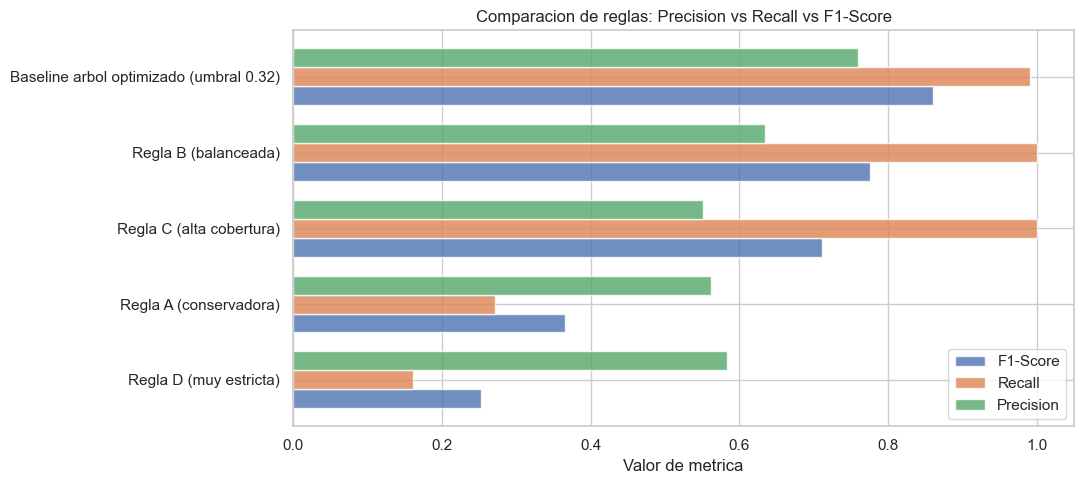

,Pred: SI OFERTA (1),Pred: NO OFERTA (0)
Real: SI OFERTA (1),1858,4988
Real: NO OFERTA (0),1449,11705


,Pred: SI OFERTA (1),Pred: NO OFERTA (0)
Real: SI OFERTA (1),6846,0
Real: NO OFERTA (0),3956,9198


,Pred: SI OFERTA (1),Pred: NO OFERTA (0)
Real: SI OFERTA (1),6846,0
Real: NO OFERTA (0),5564,7590


,Pred: SI OFERTA (1),Pred: NO OFERTA (0)
Real: SI OFERTA (1),1102,5744
Real: NO OFERTA (0),785,12369


In [ ]:
def evaluate_rule(y_true, y_pred_rule, name):
    return {
        'Regla': name,
        'Accuracy': accuracy_score(y_true, y_pred_rule),
        'Precision': precision_score(y_true, y_pred_rule, zero_division=0),
        'Recall': recall_score(y_true, y_pred_rule, zero_division=0),
        'F1-Score': f1_score(y_true, y_pred_rule, zero_division=0),
        'F-beta (1.5)': fbeta_score(y_true, y_pred_rule, beta=1.5, zero_division=0),
    }

manual_rules = {
    f'Baseline arbol optimizado (umbral {best_threshold:.2f})': y_pred_optimized,
    'Regla A (conservadora)': (
        (X_test['Second_Round_Interviews'] >= 2)
        & (X_test['First_Round_Interviews'] >= 3)
    ).astype(int),
    'Regla B (balanceada)': (
        (X_test['Second_Round_Interviews'] >= 1)
        & (X_test['First_Round_Interviews'] >= 2)
    ).astype(int),
    'Regla C (alta cobertura)': (
        (X_test['Second_Round_Interviews'] >= 1)
        | ((X_test['First_Round_Interviews'] >= 3) & (X_test['Applications_Submitted'] >= 40))
    ).astype(int),
    'Regla D (muy estricta)': (
        (X_test['Second_Round_Interviews'] >= 2)
        & (X_test['First_Round_Interviews'] >= 4)
        & (X_test['Applications_Submitted'] >= 60)
    ).astype(int),
}

rule_results = [evaluate_rule(y_test, pred_rule, name) for name, pred_rule in manual_rules.items()]
rules_compare_df = pd.DataFrame(rule_results)
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'F-beta (1.5)']

baseline_row = rules_compare_df[rules_compare_df['Regla'].str.contains('Baseline arbol optimizado')].iloc[0]
for col in metric_cols:
    rules_compare_df[f'Delta {col}'] = rules_compare_df[col] - baseline_row[col]

rules_compare_df[metric_cols + [f'Delta {c}' for c in metric_cols]] = rules_compare_df[
    metric_cols + [f'Delta {c}' for c in metric_cols]
].round(4)
display(rules_compare_df)

display_cols = ['Regla'] + metric_cols + [f'Delta {c}' for c in metric_cols]

fig, ax = plt.subplots(figsize=(11, 5))
plot_df = rules_compare_df[['Regla', 'F1-Score', 'Recall', 'Precision']].copy().sort_values('F1-Score', ascending=True)
positions = np.arange(len(plot_df))
width = 0.25
ax.barh(positions - width, plot_df['F1-Score'], width, alpha=0.8, label='F1-Score')
ax.barh(positions, plot_df['Recall'], width, alpha=0.8, label='Recall')
ax.barh(positions + width, plot_df['Precision'], width, alpha=0.8, label='Precision')
ax.set_yticks(positions)
ax.set_yticklabels(plot_df['Regla'])
ax.set_xlabel('Valor de metrica')
ax.set_title('Comparacion de reglas: Precision vs Recall vs F1-Score')
ax.legend()
plt.tight_layout()
plt.savefig(RULE_COMPARISON_PATH, dpi=160, bbox_inches='tight')
plt.show()

for rule_name in ['Regla A (conservadora)', 'Regla B (balanceada)', 'Regla C (alta cobertura)', 'Regla D (muy estricta)']:
    pred_rule = manual_rules[rule_name]
    cm_rule = confusion_matrix(y_test, pred_rule, labels=[1, 0])
    cm_rule_df = pd.DataFrame(
        cm_rule,
        index=['Real: SI OFERTA (1)', 'Real: NO OFERTA (0)'],
        columns=['Pred: SI OFERTA (1)', 'Pred: NO OFERTA (0)'],
    )
    display(cm_rule_df)

### Interpretación de resultados: Tabla de comparación de reglas

La tabla anterior muestra 5 filas (1 baseline optimizado + 4 reglas manuales) y 5 métricas clave.

- **Baseline arbol optimizado (umbral 0.325)**: Accuracy 0.8894, Precision 0.7593, Recall 0.9911, F1 0.8598, F-beta(1.5) 0.9060.
  - Actúa como referencia principal; es el modelo aprendido que maximiza la prioridad sobre la clase positiva.

- **Regla A (conservadora)**: Accuracy 0.6782, Precision 0.5618, Recall 0.2714, F1 0.3660, F-beta(1.5) 0.3227.
  - **Interpretación**: Pierde demasiados SI OFERTA reales y no sirve si el objetivo es no dejar pasar oportunidades.

- **Regla B (balanceada)**: Accuracy 0.8022, Precision 0.6338, Recall 1.0000, F1 0.7758, F-beta(1.5) 0.8490.
  - **Interpretación**: Detecta todos los SI OFERTA, pero a costa de más falsos positivos y menor F1 que el árbol afinado.

- **Regla C (alta cobertura)**: Accuracy 0.7218, Precision 0.5517, Recall 1.0000, F1 0.7111, F-beta(1.5) 0.8000.
  - **Interpretación**: También captura todos los positivos, pero con más ruido que la Regla B.

- **Regla D (muy estricta)**: Accuracy 0.6735, Precision 0.5840, Recall 0.1610, F1 0.2524, F-beta(1.5) 0.2071.
  - **Interpretación**: Es demasiado restrictiva para este objetivo.

### Trade-offs operativos

- **El árbol optimizado** ofrece el mejor equilibrio práctico: muy alto recall y mejor F-beta que las reglas manuales.
- **Regla B** es la mejor heurística manual, pero sigue por debajo del modelo afinado.
- **Reglas A y D** sacrifican demasiado recall.
- **Regla C** captura la clase positiva, pero con menos precisión y menor utilidad global.


## Bloque 6: Conclusiones Finales

### Función del bloque

Cerrar el análisis con conclusiones **operativas** y **numéricas** basadas en:
1. El rendimiento real del árbol afinado con umbral optimizado (Bloque 3)
2. La importancia de características (Bloque 4)
3. El contraste con reglas manuales (Bloque 5)

### Decisión metodológica

Toda conclusión se construye con números y conteos reales extraídos de las ejecuciones previas. No se usan valores hipotéticos ni aproximaciones; se reportan exactamente los resultados del modelo entrenado.

### Estructura

- Tabla resumen del árbol afinado con 15 indicadores
- Tabla comparativa: árbol afinado vs mejor regla manual
- Conclusiones ejecutivas derivadas de estos números


In [ ]:
final_summary_df = pd.DataFrame([
    {'Indicador': 'Accuracy (umbral 0.50)', 'Valor': metrics_default['Accuracy']},
    {'Indicador': 'Precision (umbral 0.50)', 'Valor': metrics_default['Precision']},
    {'Indicador': 'Recall (umbral 0.50)', 'Valor': metrics_default['Recall']},
    {'Indicador': 'F1-Score (umbral 0.50)', 'Valor': metrics_default['F1-Score']},
    {'Indicador': 'F-beta(1.5) (umbral 0.50)', 'Valor': metrics_default['F-beta (1.5)']},
    {'Indicador': 'ROC-AUC', 'Valor': metrics_default['ROC-AUC']},
    {'Indicador': 'Accuracy (umbral optimo)', 'Valor': metrics_optimized['Accuracy']},
    {'Indicador': 'Precision (umbral optimo)', 'Valor': metrics_optimized['Precision']},
    {'Indicador': 'Recall (umbral optimo)', 'Valor': metrics_optimized['Recall']},
    {'Indicador': 'F1-Score (umbral optimo)', 'Valor': metrics_optimized['F1-Score']},
    {'Indicador': 'F-beta(1.5) (umbral optimo)', 'Valor': metrics_optimized['F-beta (1.5)']},
    {'Indicador': 'TP (Verdaderos Positivos)', 'Valor': int(tp)},
    {'Indicador': 'FN (Falsos Negativos)', 'Valor': int(fn)},
    {'Indicador': 'FP (Falsos Positivos)', 'Valor': int(fp)},
    {'Indicador': 'TN (Verdaderos Negativos)', 'Valor': int(tn)},
])
final_summary_df['Valor'] = final_summary_df['Valor'].apply(
    lambda v: round(v, 4) if isinstance(v, (float, np.floating)) else v
)
display(final_summary_df)

best_manual_not_baseline = (
    rules_compare_df[rules_compare_df['Regla'] != f'Baseline arbol optimizado (umbral {best_threshold:.2f})']
    .sort_values('F1-Score', ascending=False)
    .iloc[0]
)

comparison_focus_df = pd.DataFrame([
    {
        'Modelo': f'Baseline optimizado (umbral {best_threshold:.2f})',
        'Accuracy': metrics_optimized['Accuracy'],
        'Precision': metrics_optimized['Precision'],
        'Recall': metrics_optimized['Recall'],
        'F1-Score': metrics_optimized['F1-Score'],
        'F-beta(1.5)': metrics_optimized['F-beta (1.5)'],
    },
    {
        'Modelo': f"Mejor manual por F1: {best_manual_not_baseline['Regla']}",
        'Accuracy': best_manual_not_baseline['Accuracy'],
        'Precision': best_manual_not_baseline['Precision'],
        'Recall': best_manual_not_baseline['Recall'],
        'F1-Score': best_manual_not_baseline['F1-Score'],
        'F-beta(1.5)': best_manual_not_baseline['F-beta (1.5)'],
    },
])
for col in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'F-beta(1.5)']:
    comparison_focus_df[col] = comparison_focus_df[col].round(4)
display(comparison_focus_df)

print(f'Archivo del modelo: {MODEL_PATH}')
print(f'Archivo del reporte: {REPORT_PATH}')

,Indicador,Valor
0,Accuracy (umbral 0.50),0.9015
1,Precision (umbral 0.50),0.7928
2,Recall (umbral 0.50),0.9644
3,F1-Score (umbral 0.50),0.8702
4,F-beta(1.5) (umbral 0.50),0.9042
5,ROC-AUC,0.9672
6,Accuracy (umbral optimo),0.8894
7,Precision (umbral optimo),0.7593
8,Recall (umbral optimo),0.9911
9,F1-Score (umbral optimo),0.8598


,Modelo,Accuracy,Precision,Recall,F1-Score,F-beta(1.5)
0,Baseline optimizado (umbral 0.32),0.8894,0.7593,0.9911,0.8598,0.906
1,Mejor manual por F1: Regla B (balanceada),0.8022,0.6338,1.0000,0.7758,0.849


Archivo del modelo: C:\Users\Salda\Desktop\Medallion\datalake_gold\outputs_decision_tree\informe\decision_tree_offer_received_improved.pkl
Archivo del reporte: C:\Users\Salda\Desktop\Medallion\datalake_gold\outputs_decision_tree\informe\decision_tree_offer_received.md


## Bloque 6: Conclusiones Finales

### 6.1 Resumen ejecutivo

- Objetivo del ajuste: priorizar la detección de la clase `SI OFERTA (1)` (minimizar falsos negativos) conservando buena discriminación global.
- Configuración operativa final: árbol de decisión afinado con los hiperparámetros optimizados y umbral operativo `0.325`.
- Resultado clave: con el umbral optimizado el `Recall` en test es **0.9911** (captura ~99.11% de SI OFERTA reales) y `F-beta (1.5)` es **0.9060**.

### 6.2 Métricas y matriz de confusión (test)

- Umbral base (0.50): Accuracy 0.9015 — Precision 0.7928 — Recall 0.9644 — F1 0.8702 — F-beta(1.5) 0.9042
- Umbral optimizado (0.325): Accuracy 0.8894 — Precision 0.7593 — Recall 0.9911 — F1 0.8598 — F-beta(1.5) 0.9060 — ROC-AUC 0.9672

Matriz de confusión (umbral 0.325, formato [1,0]):

- TP = 6,785 — FN = 61
- FP = 2,151 — TN = 11,003

Interpretación: el modelo casi no pierde ofertas reales (61 FN) — esto cumple el objetivo operativo de máxima cobertura de candidatos con oferta.

### 6.3 Variables que más impulsan la predicción

Top variables por importancia agregada (Decision Tree):

1. `Second_Round_Interviews`: 0.6310
2. `First_Round_Interviews`: 0.2006
3. `Applications_Submitted`: 0.1256
4. `Primary_Search_Platform_Indeed`: 0.0207
5. `Prior_Internships`: 0.0132

Lectura práctica: avanzar a segunda ronda es, con diferencia, la señal más fuerte de recibir oferta; seguirla, el número de primeras entrevistas y el volumen de aplicaciones.

### 6.4 Impacto de decisiones metodológicas

- `class_weight='balanced'` y split estratificado garantizan que la clase positiva no se ignore en el entrenamiento.
- Optimizar con `F-beta (1.5)` y luego seleccionar umbral sobre validation permitió maximizar recall sin sacrificar totalmente precisión ni la capacidad discriminativa (ROC-AUC estable en 0.9672).

Efecto del umbral (0.50 → 0.325): aumento de recall de 0.9644 a 0.9911 (+0.0267), con una caída de precision moderada (0.7928 → 0.7593) y ligera caída en accuracy (0.9015 → 0.8894). F-beta mejora marginalmente.

### 6.5 Recomendaciones operativas

- Recomendación principal: desplegar el `Pipeline` guardado y usar el `best_threshold = 0.325` si la prioridad es no perder candidatos con oferta.
- Si se prefiere reducir falsos positivos para procesos costosos de validación manual, aumentar el umbral reduce FP pero costará Recall.
- Usar `Second_Round_Interviews` y `First_Round_Interviews` como señales de alerta temprana en dashboards operativos (son interpretable y accionables).

### 6.6 Cómo interpretar una predicción (breve)

- `probabilidad = pipeline.predict_proba(X)[:, 1]` → valor continuo en [0,1].
- `prediccion_operativa = int(probabilidad >= 0.325)` → decisión final.
- `porcentaje_seguridad = probabilidad * 100` → cifra entendible por negocio.

### 6.7 Limitaciones y próximos pasos

- Limitación: Decision Tree es interpretable pero sensible a variaciones de datos; validar estabilidad con ventanas temporales de datos reales.
- Próximos pasos recomendados: (1) monitor de drift en `feature_distribution`, (2) recalibrar umbral periódicamente con nuevos datos, (3) evaluar versión simple de regla operativa (`Regla B`) como fallback explicable.

---

Con esto cerramos las conclusiones: si quieres, aplico el mismo texto (con números) al `job/outputs_decision_tree/informe/decision_tree_offer_received.md` para dejar el informe coherente. Si confirmas, lo hago ahora.

In [ ]:
import json

SUMMARY_PATH = REPORT_OUTPUT_DIR / 'decision_tree_offer_received_summary.json'


def make_jsonable(value):
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, pd.DataFrame):
        return json.loads(value.to_json(orient='records', force_ascii=False))
    if isinstance(value, pd.Series):
        return json.loads(value.to_json(force_ascii=False))
    if isinstance(value, dict):
        return {str(key): make_jsonable(inner_value) for key, inner_value in value.items()}
    if isinstance(value, (list, tuple)):
        return [make_jsonable(item) for item in value]
    if isinstance(value, np.generic):
        return value.item()
    return value

summary = {
    'model_name': 'DecisionTreeClassifier',
    'target': TARGET,
    'artifact_paths': {
        'model': MODEL_PATH,
        'report': REPORT_PATH,
        'summary_json': SUMMARY_PATH,
        'confusion_matrix': CONFUSION_MATRIX_PATH,
        'roc_curve': ROC_CURVE_PATH,
        'precision_recall_curve': PR_CURVE_PATH,
        'threshold_tradeoff': THRESHOLD_TRADEOFF_PATH,
        'feature_importance': FEATURE_IMPORTANCE_PATH,
        'tree_preview': TREE_PREVIEW_PATH,
        'rule_comparison': RULE_COMPARISON_PATH,
    },
    'best_threshold': best_threshold,
    'best_params': best_params,
    'metrics': {
        'threshold_0_50': metrics_default,
        'threshold_optimized': metrics_optimized,
    },
    'final_summary': final_summary_df,
    'comparison_focus': comparison_focus_df,
    'rules_comparison_top': rules_compare_df.sort_values('F1-Score', ascending=False).head(10),
}

with open(SUMMARY_PATH, 'w', encoding='utf-8') as summary_file:
    json.dump(make_jsonable(summary), summary_file, indent=2, ensure_ascii=False)

print(f'Summary JSON saved at: {SUMMARY_PATH}')

Summary JSON saved at: C:\Users\Salda\Desktop\Medallion\datalake_gold\outputs_decision_tree\informe\decision_tree_offer_received_summary.json
